Power (n) Dimension   Min Delta   Max Delta   Mean Delta  
--------------------------------------------------------------
2^1       2           -0.00000    0.00000     -0.00000    
2^2       4           -0.00000    0.00000     0.00000     
2^3       8           -0.00000    0.00000     0.00000     
2^4       16          -0.29263    0.54258     -0.01143    
2^5       32          -0.26690    0.31137     0.01306     
2^6       64          -0.14718    0.25299     0.00801     
2^7       128         -0.13900    0.25551     0.02321     
2^8       256         -0.11372    0.14878     0.00360     
2^9       512         -0.10045    0.10216     -0.00869    
2^10      1024        -0.05665    0.10471     0.00840     
2^11      2048        -0.03316    0.03729     0.00068     
2^12      4096        -0.02972    0.02735     -0.00126    
2^13      8192        -0.02570    0.01999     0.00075     


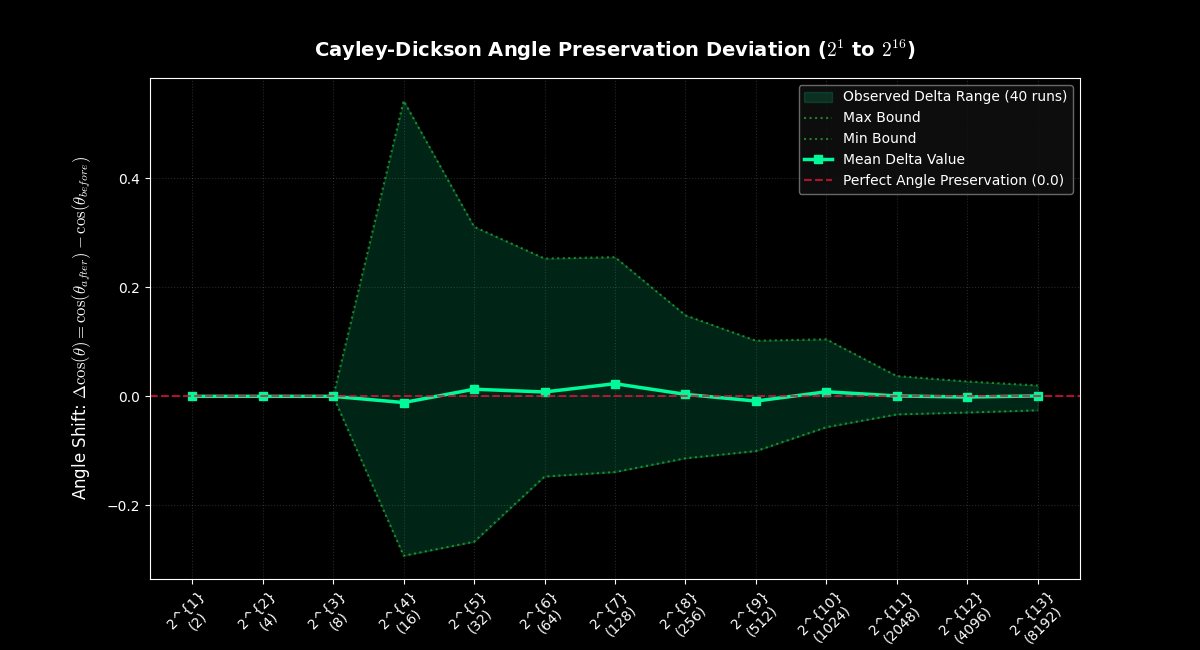

In [1]:
# Pychon Code: Angular Preservation

%matplotlib widget
import cupy as cp
import matplotlib.pyplot as plt
from CayleyKernel import multiply

# FIX: Set the math font package to fully support Greek letters and symbols
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern (Standard LaTeX look)
# OR alternatively: plt.rcParams['mathtext.fontset'] = 'stix'

LEVELS = 13

def angle_preservation_ranges():
    # Set dark theme styling for the plot
    plt.style.use('dark_background')

    powers = list(range(1, LEVELS+1))
    dimensions = [2**p for p in powers]
    num_tests = 40

    mins = []
    maxs = []
    means = []

    print(f"{'Power (n)':<10}{'Dimension':<12}{'Min Delta':<12}{'Max Delta':<12}{'Mean Delta':<12}")
    print("-" * 62)

    for p, dim in zip(powers, dimensions):
        delta_cosines = []

        for _ in range(num_tests):
            # Generate 3 random vectors
            a = cp.random.randn(dim, dtype=cp.float32)
            b = cp.random.randn(dim, dtype=cp.float32)
            c = cp.random.randn(dim, dtype=cp.float32)

            # Normalize to unit vectors to simplify cosine calculation
            a /= cp.linalg.norm(a)
            b /= cp.linalg.norm(b)
            c /= cp.linalg.norm(c)

            # Before multiplication: cos(theta) is just the inner product of unit vectors
            cos_before = float(cp.dot(b, c))

            # Multiply both by a using your custom module
            #ab = dlm.mult(a, b)
            #ac = dlm.mult(a, c)
            ab = multiply(a, b)
            ac = multiply(a, c)

            # After multiplication: calculate the new cosine angle
            norm_ab = cp.linalg.norm(ab)
            norm_ac = cp.linalg.norm(ac)

            # Safe guard against division by zero (unlikely with random inputs)
            if norm_ab > 0 and norm_ac > 0:
                cos_after = float(cp.dot(ab, ac) / (norm_ab * norm_ac))
            else:
                cos_after = cos_before

            # Delta cosine deviation
            delta_cosines.append(cos_after - cos_before)

        # Calculate statistics across the 40 runs
        deltas_cp = cp.array(delta_cosines)
        min_d = float(cp.min(deltas_cp))
        max_d = float(cp.max(deltas_cp))
        mean_d = float(cp.mean(deltas_cp))

        mins.append(min_d)
        maxs.append(max_d)
        means.append(mean_d)

        print(f"2^{p:<8}{dim:<12}{min_d:<12.5f}{max_d:<12.5f}{mean_d:<12.5f}")

    # --- Dark Themed Plotting ---
    fig, ax = plt.subplots(figsize=(12, 6.5), facecolor='black')

    # Fill the range between minimum and maximum observed angle deviations
    ax.fill_between(powers, mins, maxs, color='mediumspringgreen', alpha=0.15, label='Observed Delta Range (40 runs)')

    # Plot outer boundaries and the statistical average
    ax.plot(powers, maxs, color='limegreen', linestyle=':', alpha=0.6, linewidth=1.5, label='Max Bound')
    ax.plot(powers, mins, color='limegreen', linestyle=':', alpha=0.6, linewidth=1.5, label='Min Bound')
    ax.plot(powers, means, marker='s', color='mediumspringgreen', linewidth=2.5, label='Mean Delta Value')

    # Baseline for perfect angle preservation (zero change)
    ax.axhline(y=0.0, color='crimson', linestyle='--', alpha=0.8, linewidth=1.5, label='Perfect Angle Preservation (0.0)')

    # Title and labels (Using raw strings to prevent syntax warnings)
    ax.set_title(r'Cayley-Dickson Angle Preservation Deviation ($2^1$ to $2^{16}$)', fontsize=14, fontweight='bold', pad=15, color='white')
    ax.set_xlabel(r'Dimension Power ($n$ in $2^n$)', fontsize=12, labelpad=10, color='white')
    ax.set_ylabel(r'Angle Shift: $\Delta \cos(\theta) = \cos(\theta_{after}) - \cos(\theta_{before})$', fontsize=12, labelpad=10, color='white')

    ## Format grid and ticks
    ax.set_xticks(powers)
    ax.set_xticklabels([f"2^{{{p}}}\n({2**p})" for p in powers], rotation=45, color='white')

    ax.grid(True, linestyle=':', alpha=0.3, color='gray')

    # Adjust legend position and styling
    ax.legend(fontsize=10, loc='best', facecolor='#111111', edgecolor='gray')
    #plt.tight_layout()

    # Show window on frame
    plt.show()

if __name__ == "__main__":
    angle_preservation_ranges()
